---
title: "Birth, Wealth, and Income Analysis"
description: "An analysis of generational mobility data."
date: "2026-05-01"
categories: [Python, Economics]
---

In [3]:
# Install required libraries if needed
!pip install pandas-datareader matplotlib seaborn

In [4]:
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [5]:
# 1. Adjust timeframe to start at the post-WWII baseline (1945)
start_date = datetime(1945, 1, 1)
end_date = datetime(2026, 1, 1)

In [6]:
import pandas as pd
from fredapi import Fred

fred = Fred(api_key='dc1751429339ed200eb730b2ce033b53')

series_dict = {
    'Birth_Rate_Per_1000': 'SPDYNCBRTINUSA',
    'Real_GDP_Per_Capita': 'A939RX0Q048SBEA',
    'Household_Net_Worth': 'HNONWRA027N'  # Corrected from HNOTNWA027S
}

df_list = []
for name, series_id in series_dict.items():
    s = fred.get_series(series_id, observation_start='1945-01-01')
    df_list.append(s.rename(name))

df_raw = pd.concat(df_list, axis=1, sort=True)
df_annual = df_raw.resample('YE').mean()
df_annual.index = df_annual.index.year
df_clean = df_annual.dropna()

print(df_clean.head())

      Birth_Rate_Per_1000  Real_GDP_Per_Capita  Household_Net_Worth
1960                 23.7             19365.25            2091056.0
1961                 23.3             19537.50            2256719.0
1962                 22.4             20419.25            2319203.0
1963                 21.7             21003.50            2422670.0
1964                 21.1             21910.25            2604188.0


In [7]:
# 3. Clean and Resample Data
# Using 'YE' (Year End) to align with modern pandas standards
df_annual = df_raw.resample('YE').mean()
df_annual.index = df_annual.index.year  # Convert index to simple Year integers
df_clean = df_annual.dropna()           # Drop rows missing any of the 3 metrics

print("\nData Sample (First 5 Years):")
print(df_clean.head())


Data Sample (First 5 Years):
      Birth_Rate_Per_1000  Real_GDP_Per_Capita  Household_Net_Worth
1960                 23.7             19365.25            2091056.0
1961                 23.3             19537.50            2256719.0
1962                 22.4             20419.25            2319203.0
1963                 21.7             21003.50            2422670.0
1964                 21.1             21910.25            2604188.0


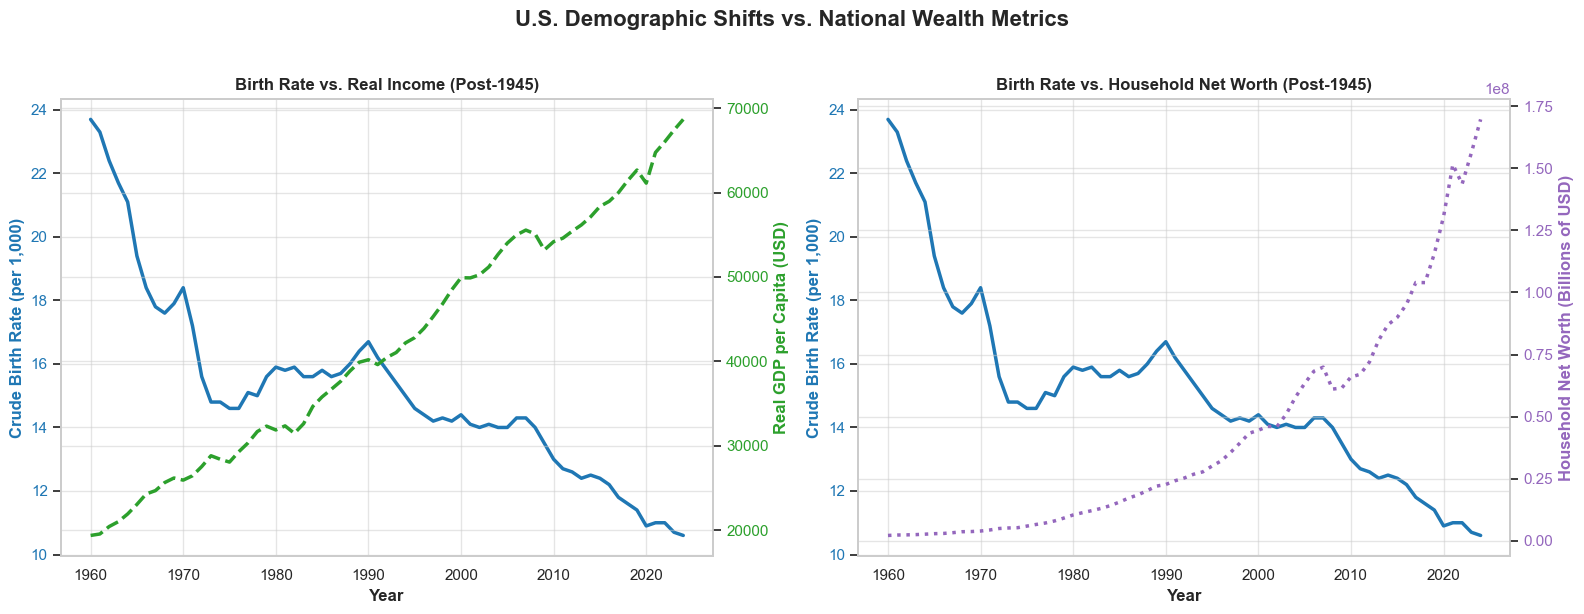

In [8]:
# 4. Visualization: Two Plots Side-by-Side for Comparison
sns.set_theme(style="whitegrid")
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: Birth Rate vs. Income (Real GDP) ---
color_birth = '#1f77b4'
ax1.set_xlabel('Year', fontweight='bold')
ax1.set_ylabel('Crude Birth Rate (per 1,000)', color=color_birth, fontweight='bold')
line1 = ax1.plot(df_clean.index, df_clean['Birth_Rate_Per_1000'], color=color_birth, linewidth=2.5, label='Birth Rate')
ax1.tick_params(axis='y', labelcolor=color_birth)

ax2 = ax1.twinx()
color_income = '#2ca02c'
ax2.set_ylabel('Real GDP per Capita (USD)', color=color_income, fontweight='bold')
line2 = ax2.plot(df_clean.index, df_clean['Real_GDP_Per_Capita'], color=color_income, linewidth=2.5, linestyle='--', label='Real GDP Per Capita')
ax2.tick_params(axis='y', labelcolor=color_income)

ax1.set_title('Birth Rate vs. Real Income (Post-1945)', fontsize=12, fontweight='bold')

# --- PLOT 2: Birth Rate vs. Aggregate Household Net Worth ---
ax3.set_xlabel('Year', fontweight='bold')
ax3.set_ylabel('Crude Birth Rate (per 1,000)', color=color_birth, fontweight='bold')
line3 = ax3.plot(df_clean.index, df_clean['Birth_Rate_Per_1000'], color=color_birth, linewidth=2.5, label='Birth Rate')
ax3.tick_params(axis='y', labelcolor=color_birth)

ax4 = ax3.twinx()
color_wealth = '#9467bd'  # Purple for wealth
ax4.set_ylabel('Household Net Worth (Billions of USD)', color=color_wealth, fontweight='bold')
line4 = ax4.plot(df_clean.index, df_clean['Household_Net_Worth'], color=color_wealth, linewidth=2.5, linestyle=':', label='Household Net Worth')
ax4.tick_params(axis='y', labelcolor=color_wealth)

ax3.set_title('Birth Rate vs. Household Net Worth (Post-1945)', fontsize=12, fontweight='bold')

plt.suptitle('U.S. Demographic Shifts vs. National Wealth Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# 5. Output Correlation Summary
print("\n--- Correlation Matrix ---")
print(df_clean.corr()['Birth_Rate_Per_1000'])


--- Correlation Matrix ---
Birth_Rate_Per_1000    1.000000
Real_GDP_Per_Capita   -0.870522
Household_Net_Worth   -0.775335
Name: Birth_Rate_Per_1000, dtype: float64
